<hr>

# 🤖 MACHINE LEARNING 🤖

<style>
h1 {
    text-align: center;
    color: hotpink;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<hr>

In [2]:
!pip install xgboost

In [3]:
import pandas as pd
from sklearn.metrics import accuracy_score  
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, average_precision_score
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import numpy as np


In [4]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

# XGBoost model

## Scale POS weight  - XGBoost

In [5]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
base_spw = neg / pos

print("neg:", neg, "pos:", pos, "base scale_pos_weight:", base_spw)

neg: 8338 pos: 1526 base scale_pos_weight: 5.463958060288335


## PR curve for optimal SPW = 3

PR AUC (Test): 0.7477639633449442


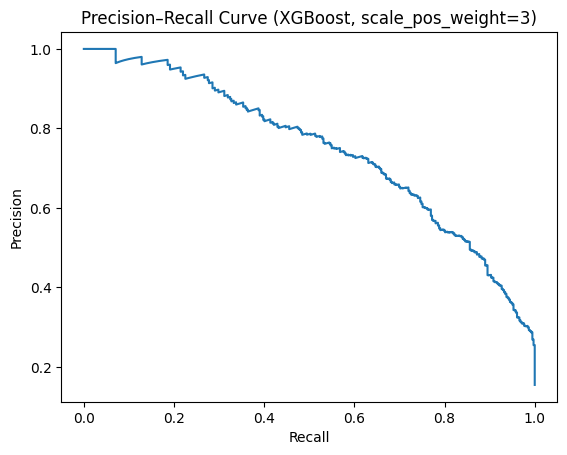

In [6]:
# XGBoost with scale_pos_weight = 3
xgb_spw3 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=42,
    eval_metric="logloss"
)

xgb_spw3.fit(X_train, y_train)

# Predicted probabilities on TEST set
y_test_proba_spw3 = xgb_spw3.predict_proba(X_test)[:, 1]

# Precision-Recall curve points
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba_spw3)

# PR AUC (Average Precision)
pr_auc = average_precision_score(y_test, y_test_proba_spw3)
print("PR AUC (Test):", pr_auc)

# Plot PR curve
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (XGBoost, scale_pos_weight=3)")
plt.show()

## Probability Threshold Adjustments

In [7]:
#PR threshold
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba_spw3)

#creating a table of thresholds, precision, and recall
pr_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

pr_df.head(10)

,threshold,precision,recall
0,0.000356,0.154907,1.0
1,0.000417,0.154970,1.0
2,0.000430,0.155032,1.0
3,0.000499,0.155095,1.0
4,0.000510,0.155158,1.0
5,0.000531,0.155221,1.0
6,0.000537,0.155285,1.0
7,0.000574,0.155348,1.0
8,0.000598,0.155411,1.0
9,0.000608,0.155474,1.0


## Best F1

In [8]:
pr_df["f1"] = 2 * (pr_df["precision"] * pr_df["recall"]) / (pr_df["precision"] + pr_df["recall"])
pr_df.loc[pr_df["f1"].idxmax()]

threshold    0.584653
precision    0.651659
recall       0.719895
f1           0.684080
Name: 2032, dtype: float64

Business Interpretation:

- Nudges like Discount codes (10–20% off), Cashback offers, Free shipping, Personalized coupon campaigns, limited time deals on price are expensive, so we'll have to strike a balance between the recall and precision

- Recall  = 0.72 means we capture 72% of all converters

- Precision = 0.64 means of customers we target, 64% convert, 36% nudges go to non-converters ~ this means a controlled marketing budget expenditure

# Saving plk file for deployment

In [9]:
import xgboost as xgb
import pickle

In [10]:
with open ("../models/xgb_spw3_model.pkl", "wb") as f:
    pickle.dump(xgb_spw3, f)

# **Feature Selection**
Use `feature_importances_`

                           feature  importance
8                       page_value    0.223947
18                       month_Nov    0.068556
17                       month_May    0.045575
16                       month_Mar    0.042456
20                       month_Sep    0.028040
7                        exit_rate    0.020732
6                      bounce_rate    0.019532
21        visitor_type_New_Visitor    0.018361
5            prod_related_duration    0.017154
0                            admin    0.016815
56                  traffic_type_3    0.016505
61                  traffic_type_8    0.014697
4                     prod_related    0.014357
23  visitor_type_Returning_Visitor    0.014340
14                       month_Jul    0.014199


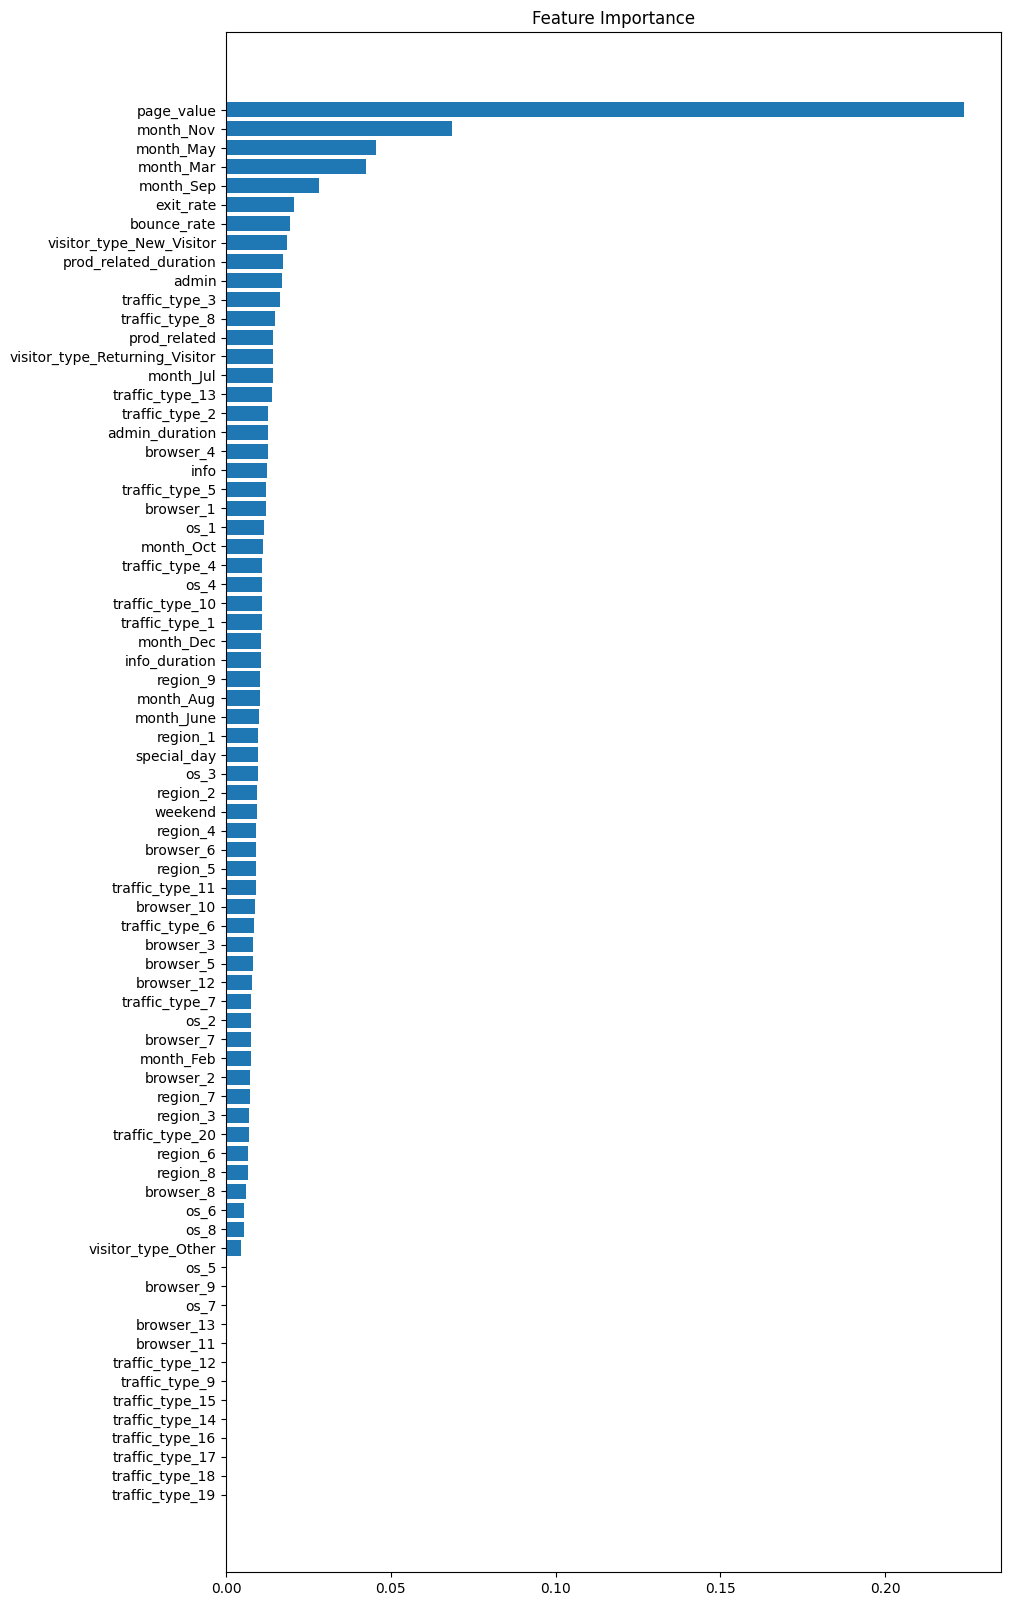

In [11]:
# Get importance
importances = xgb_spw3.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_spw3.feature_importances_
})

# Sort descending
feat_imp = feat_imp.sort_values(by="importance", ascending=False)

# print top 15 features
print(feat_imp.head(15))


# PLOT FEATURE IMPORTANCE
plt.figure(figsize=(10,20))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

# page_value, month, bounce_rate, 

# import and install shap

In [12]:
import shap
import matplotlib.pyplot as plt
!pip install shap

# import and install shap

In [16]:
# --------------------------------------------------
# SHAP EXPLAINER
# --------------------------------------------------

import shap
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import streamlit as st

model = xgb_spw3

# --------------------------------------------------
# DEFINE INPUT DATA FROM MODEL FEATURES
# --------------------------------------------------

data = {}

# Automatically create inputs based on model features
for feature in model.feature_names_in_:
    data[feature] = st.number_input(feature, value=0.0)

# Create DataFrame for Prediction
input_df = pd.DataFrame([data])

# Ensure correct feature order
input_df = input_df[model.feature_names_in_]

# Prediction
prediction = model.predict(input_df)
prob = model.predict_proba(input_df)
purchase_prob = prob[0][1] * 100

# --------------------------------------------------
# AI EXPLAINABILITY (SHAP)
# --------------------------------------------------

st.divider()
st.header("🧠 AI Decision Explanation")

# Create SHAP explainer
explainer = shap.Explainer(model)

# Compute SHAP values
shap_values = explainer(input_df)

# Extract contributions
values = shap_values.values[0]

feature_contrib = pd.DataFrame({
    "Feature": input_df.columns,
    "Contribution": values
})

# Absolute importance
feature_contrib["abs"] = feature_contrib["Contribution"].abs()

# Top features
top_features = feature_contrib.sort_values(
    "abs", ascending=False
).head(10)

# --------------------------------------------------
# SHAP Waterfall Plot
# --------------------------------------------------

st.subheader("Prediction Explanation")

fig = plt.figure()

shap.plots.waterfall(
    shap_values[0],
    show=False
)

st.pyplot(fig)

# --------------------------------------------------
# Top Feature Drivers Chart
# --------------------------------------------------

st.subheader("Top Factors Influencing Conversion")

fig2 = px.bar(
    top_features.sort_values("Contribution"),
    x="Contribution",
    y="Feature",
    orientation="h",
    title="Feature Influence on Conversion Probability"
)

st.plotly_chart(fig2, use_container_width=True)

# --------------------------------------------------
# Automatic Interpretation
# --------------------------------------------------

positive = feature_contrib.sort_values(
    "Contribution", ascending=False
).head(3)

negative = feature_contrib.sort_values(
    "Contribution"
).head(3)

st.subheader("AI Insights")

st.write("### Drivers Increasing Conversion")

for _, row in positive.iterrows():
    st.success(f"{row['Feature']} increases purchase likelihood")

st.write("### Drivers Reducing Conversion")

for _, row in negative.iterrows():
    st.warning(f"{row['Feature']} reduces purchase likelihood")

2026-03-06 14:59:15.147 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 14:59:15.149 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 14:59:15.150 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 14:59:15.151 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-06 14:59:15.152 WARNING streamlit.runtime.state.session_state_proxy: Session state does not function when running a script without `streamlit run`
2026-03-06 14:59:15.153 WARNING streamlit.runtime.scriptrunner_utils.script_run_c

TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)